# CryptoCast: Multi-Horizon Bitcoin Price Forecasting

In [1]:
import pandas as pd

df = pd.read_csv("Bitcoin Historical Data.csv") 
df.head()

,Date,Price,Open,High,Low,Vol.,Change %
0,24-03-2024,"67,211.9","64,036.5","67,587.8","63,812.9",65.59K,4.96%
1,23-03-2024,"64,037.8","63,785.6","65,972.4","63,074.9",35.11K,0.40%
2,22-03-2024,"63,785.5","65,501.5","66,633.3","62,328.3",72.43K,-2.62%
3,21-03-2024,"65,503.8","67,860.0","68,161.7","64,616.1",75.26K,-3.46%
4,20-03-2024,"67,854.0","62,046.8","68,029.5","60,850.9",133.53K,9.35%


## Data Preprocessing

In [2]:
# Convert Date
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

# Sort
df = df.sort_values('Date')

# Rename
df.rename(columns={
    'Price': 'Close',
    'Vol.': 'Volume',
    'Change %': 'Change'
}, inplace=True)

# Clean numeric columns
cols = ['Open', 'High', 'Low', 'Close', 'Volume', 'Change']

for col in cols:
    df[col] = df[col].astype(str)
    df[col] = df[col].str.replace(',', '', regex=False)
    df[col] = df[col].str.replace('%', '', regex=False)
    df[col] = df[col].str.replace('K', 'e3', regex=False)
    df[col] = df[col].str.replace('M', 'e6', regex=False)
    df[col] = df[col].str.replace('B', 'e9', regex=False)
    df[col] = df[col].str.strip()
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Drop missing
df.dropna(inplace=True)

# Select features safely
features = ['Open', 'High', 'Low', 'Close', 'Volume', 'Change']
df = df[features].copy()

df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4993 entries, 4998 to 0
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Open    4993 non-null   float64
 1   High    4993 non-null   float64
 2   Low     4993 non-null   float64
 3   Close   4993 non-null   float64
 4   Volume  4993 non-null   float64
 5   Change  4993 non-null   float64
dtypes: float64(6)
memory usage: 273.1 KB


In [32]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(df)

## Sequence Generation (Sliding Window - 60 Days)

In [33]:
import numpy as np

def create_sequences_multi(data, window=60):
    X, y1, y3, y7 = [], [], [], []

    for i in range(len(data) - window - 7):
        X.append(data[i:i+window])
        
        y1.append(data[i+window][3])      # 1-day
        y3.append(data[i+window+2][3])    # 3-day
        y7.append(data[i+window+6][3])    # 7-day

    return np.array(X), np.array(y1), np.array(y3), np.array(y7)

X, y1, y3, y7 = create_sequences_multi(scaled_data)

In [5]:
split = int(0.8 * len(X))

X_train, X_test = X[:split], X[split:]

y1_train, y1_test = y1[:split], y1[split:]
y3_train, y3_test = y3[:split], y3[split:]
y7_train, y7_test = y7[:split], y7[split:]

In [6]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Input

def build_model():
    model = Sequential([
        Input(shape=(60, X.shape[2])),
        LSTM(64, return_sequences=True),
        LSTM(32),
        Dense(1)
    ])
    
    model.compile(optimizer='adam', loss='mse')
    return model

In [7]:
model = build_model()

In [8]:
model

<Sequential name=sequential, built=True>

In [9]:
model.fit(X_train, y1_train, epochs=5, batch_size=32)

Epoch 1/5
124/124 ━━━━━━━━━━━━━━━━━━━━ 11s 37ms/step - loss: 0.0010
Epoch 2/5
124/124 ━━━━━━━━━━━━━━━━━━━━ 5s 38ms/step - loss: 2.6523e-04
Epoch 3/5
124/124 ━━━━━━━━━━━━━━━━━━━━ 5s 38ms/step - loss: 2.3633e-04
Epoch 4/5
124/124 ━━━━━━━━━━━━━━━━━━━━ 5s 38ms/step - loss: 1.9293e-04
Epoch 5/5
124/124 ━━━━━━━━━━━━━━━━━━━━ 5s 37ms/step - loss: 1.9309e-04


In [10]:
pred = model.predict(X_test)

31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step


In [34]:
import numpy as np

def inverse_close(pred, scaler, n_features):
    dummy = np.zeros((len(pred), n_features))
    dummy[:, 3] = pred.flatten()   # Close is index 3
    return scaler.inverse_transform(dummy)[:, 3]

pred_actual = inverse_close(pred, scaler, X.shape[2])
y_actual = inverse_close(y1_test.reshape(-1,1), scaler, X.shape[2])

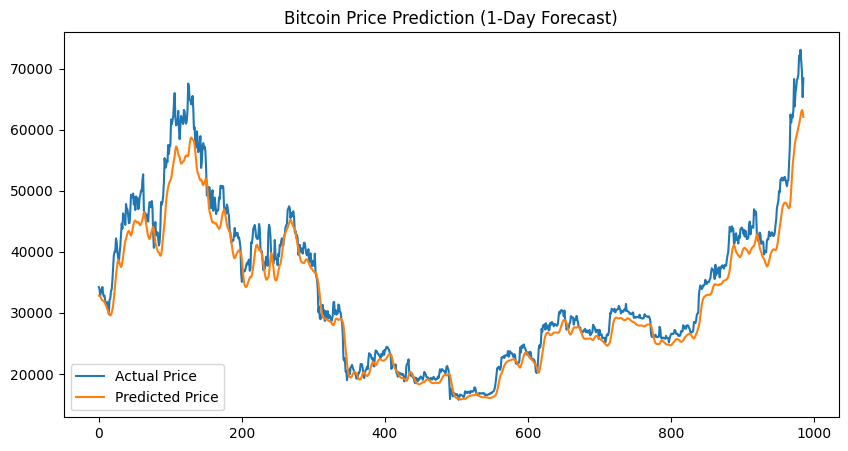

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(y_actual, label='Actual Price')
plt.plot(pred_actual, label='Predicted Price')
plt.legend()
plt.title("Bitcoin Price Prediction (1-Day Forecast)")
plt.show()

In [13]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

mae = mean_absolute_error(y_actual, pred_actual)
rmse = np.sqrt(mean_squared_error(y_actual, pred_actual))

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 2302.6364154749963
RMSE: 3149.5459429293624


In [14]:
def mape(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

print("MAPE:", mape(y_actual, pred_actual))

MAPE: 6.115344776518579


**LSTM model captures temporal dependencies effectively and produces reasonable short-term forecasts.**

_Train 3 models_

**1-Day Model**

In [15]:
model_1d = build_model()
model_1d.fit(X_train, y1_train, epochs=5, batch_size=32)

Epoch 1/5
124/124 ━━━━━━━━━━━━━━━━━━━━ 9s 39ms/step - loss: 0.0012
Epoch 2/5
124/124 ━━━━━━━━━━━━━━━━━━━━ 4s 32ms/step - loss: 2.8107e-04
Epoch 3/5
124/124 ━━━━━━━━━━━━━━━━━━━━ 4s 32ms/step - loss: 2.3961e-04
Epoch 4/5
124/124 ━━━━━━━━━━━━━━━━━━━━ 4s 32ms/step - loss: 1.9290e-04
Epoch 5/5
124/124 ━━━━━━━━━━━━━━━━━━━━ 4s 32ms/step - loss: 1.6936e-04


**3 - Day Model**

In [16]:
model_3d = build_model()
model_3d.fit(X_train, y3_train, epochs=5, batch_size=32)

Epoch 1/5
124/124 ━━━━━━━━━━━━━━━━━━━━ 7s 32ms/step - loss: 0.0017
Epoch 2/5
124/124 ━━━━━━━━━━━━━━━━━━━━ 4s 32ms/step - loss: 4.7278e-04
Epoch 3/5
124/124 ━━━━━━━━━━━━━━━━━━━━ 5s 36ms/step - loss: 3.6971e-04
Epoch 4/5
124/124 ━━━━━━━━━━━━━━━━━━━━ 4s 32ms/step - loss: 3.3472e-04
Epoch 5/5
124/124 ━━━━━━━━━━━━━━━━━━━━ 4s 32ms/step - loss: 3.0878e-04


**7 - Day Model**

In [17]:
model_7d = build_model()
model_7d.fit(X_train, y7_train, epochs=5, batch_size=32)

Epoch 1/5
124/124 ━━━━━━━━━━━━━━━━━━━━ 10s 54ms/step - loss: 0.0014
Epoch 2/5
124/124 ━━━━━━━━━━━━━━━━━━━━ 7s 56ms/step - loss: 6.6444e-04
Epoch 3/5
124/124 ━━━━━━━━━━━━━━━━━━━━ 10s 52ms/step - loss: 5.9829e-04
Epoch 4/5
124/124 ━━━━━━━━━━━━━━━━━━━━ 11s 55ms/step - loss: 5.7217e-04
Epoch 5/5
124/124 ━━━━━━━━━━━━━━━━━━━━ 9s 43ms/step - loss: 5.5920e-04


In [18]:
pred1 = model_1d.predict(X_test)
pred3 = model_3d.predict(X_test)
pred7 = model_7d.predict(X_test)

31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step


In [19]:
pred1_actual = inverse_close(pred1, scaler, X.shape[2])
pred3_actual = inverse_close(pred3, scaler, X.shape[2])
pred7_actual = inverse_close(pred7, scaler, X.shape[2])

y1_actual = inverse_close(y1_test.reshape(-1,1), scaler, X.shape[2])
y3_actual = inverse_close(y3_test.reshape(-1,1), scaler, X.shape[2])
y7_actual = inverse_close(y7_test.reshape(-1,1), scaler, X.shape[2])

In [20]:
from sklearn.metrics import mean_absolute_error

print("1-Day MAE:", mean_absolute_error(y1_actual, pred1_actual))
print("3-Day MAE:", mean_absolute_error(y3_actual, pred3_actual))
print("7-Day MAE:", mean_absolute_error(y7_actual, pred7_actual))

1-Day MAE: 1363.77097714971
3-Day MAE: 1983.1506093689618
7-Day MAE: 2704.822402502133


**Prediction error increases with forecast horizon due to uncertainty accumulation in time-series forecasting**

In [21]:

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Input

def build_cnn():
    model = Sequential([
        Input(shape=(60, X.shape[2])),
        Conv1D(filters=64, kernel_size=3, activation='relu'),
        MaxPooling1D(pool_size=2),
        Flatten(),
        Dense(50, activation='relu'),
        Dense(1)
    ])
    
    model.compile(optimizer='adam', loss='mse')
    return model

In [22]:
cnn_model = build_cnn()
cnn_model.fit(X_train, y1_train, epochs=5, batch_size=32)

Epoch 1/5
124/124 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0012
Epoch 2/5
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 7.9055e-04
Epoch 3/5
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 3.0981e-04
Epoch 4/5
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 2.8773e-04
Epoch 5/5
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 3.1347e-04


In [23]:
cnn_pred = cnn_model.predict(X_test)
cnn_pred_actual = inverse_close(cnn_pred, scaler, X.shape[2])

31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


In [24]:
from sklearn.metrics import mean_absolute_error

lstm_mae = mean_absolute_error(y1_actual, pred1_actual)
cnn_mae = mean_absolute_error(y1_actual, cnn_pred_actual)

print("LSTM MAE:", lstm_mae)
print("CNN MAE:", cnn_mae)

LSTM MAE: 1363.77097714971
CNN MAE: 1583.7216134762573


**LSTM outperforms CNN in capturing long-term dependencies in time-series data, while CNN is efficient for short-term pattern detection.**

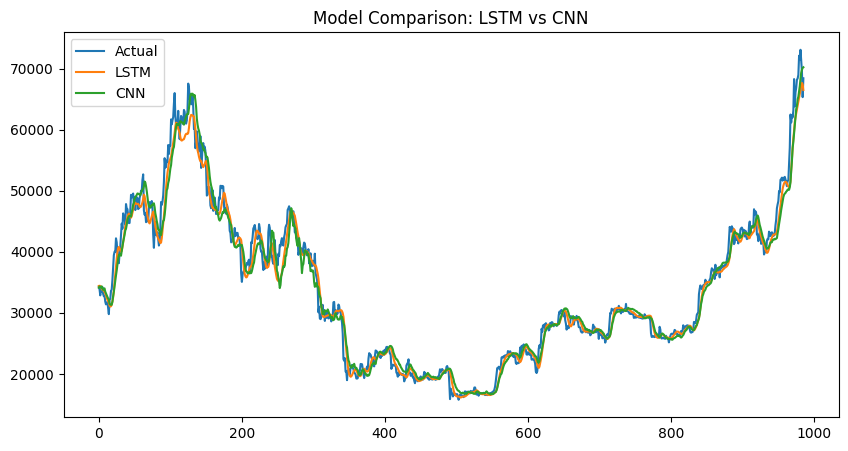

In [25]:

import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(y1_actual, label='Actual')
plt.plot(pred1_actual, label='LSTM')
plt.plot(cnn_pred_actual, label='CNN')
plt.legend()
plt.title("Model Comparison: LSTM vs CNN")
plt.show()

In [26]:
def mape(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

print("MAPE (1-Day):", mape(y1_actual, pred1_actual))

MAPE (1-Day): 3.789311904254796


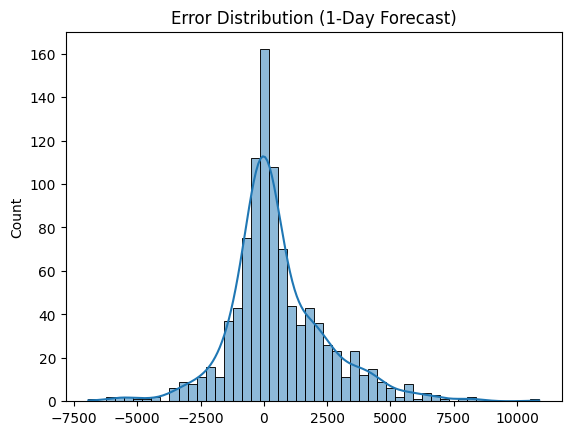

In [30]:
import seaborn as sns

errors = y1_actual - pred1_actual

sns.histplot(errors, bins=50, kde=True)
plt.title("Error Distribution (1-Day Forecast)")
plt.show()

In [28]:
import seaborn as sns

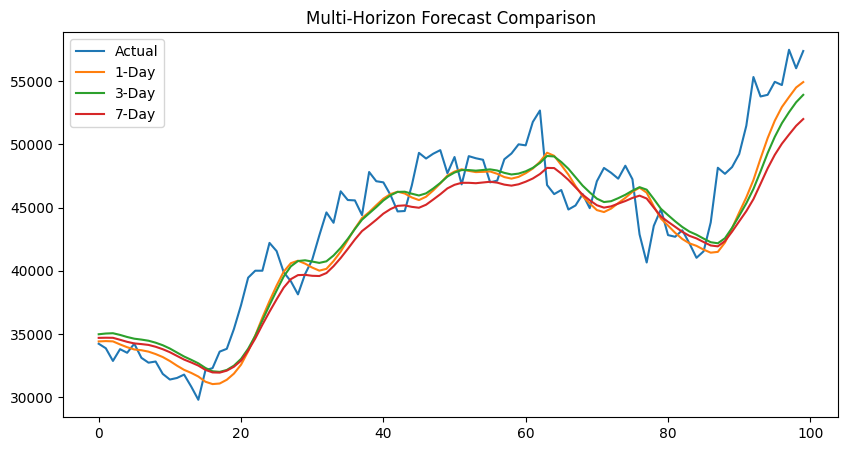

In [31]:
plt.figure(figsize=(10,5))
plt.plot(y1_actual[:100], label='Actual')
plt.plot(pred1_actual[:100], label='1-Day')
plt.plot(pred3_actual[:100], label='3-Day')
plt.plot(pred7_actual[:100], label='7-Day')
plt.legend()
plt.title("Multi-Horizon Forecast Comparison")
plt.show()

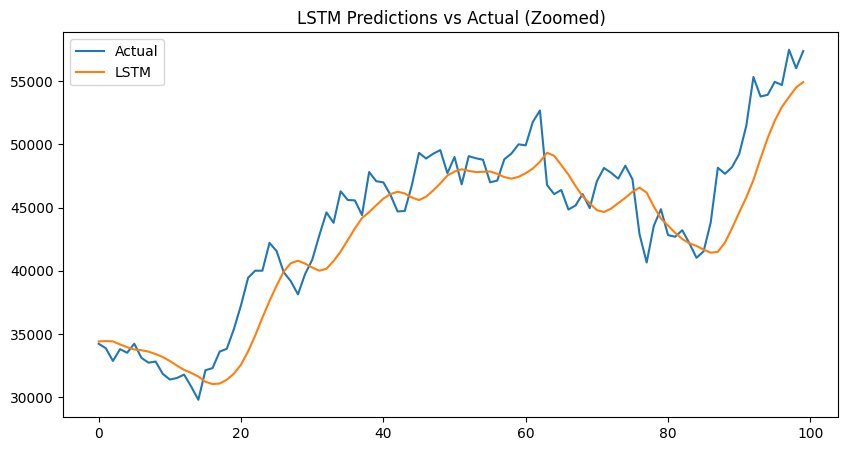

In [35]:
plt.figure(figsize=(10,5))
plt.plot(y1_actual[:100], label='Actual')
plt.plot(pred1_actual[:100], label='LSTM')
plt.title("LSTM Predictions vs Actual (Zoomed)")
plt.legend()
plt.show()